# Phase 3: Predictive Modeling
# Executive Summary
Phase 3 develops predictive models to understand the operational drivers behind readmission, cost, and patient satisfaction. These models build on the patterns uncovered in Phase 2 and quantify how patient demographics, clinical conditions, and procedures influence key hospital outcomes. The readmission model highlights cardiac and stroke-related conditions as the strongest predictors of return visits. The cost model achieves perfect accuracy due to the synthetic dataset structure, where each condition and procedure maps to a fixed cost. The satisfaction model shows that age and condition severity are the primary drivers of patient experience. Together, these models provide a data-driven foundation for improving care pathways, resource planning, and patient engagement strategies.

### Introduction
Phase 3 focuses on building predictive models that explain and forecast key operational outcomes. The primary targets include readmission, cost, and satisfaction. Insights from Phase 2 guide expectations and help shape the modeling strategy.

### Library Imports and Data Loading
This section loads all required Python libraries and imports the cleaned dataset.  
Basic structure and data types are reviewed to confirm readiness for modeling.

In [1]:
# Import core libraries for data manipulation, visualization, and modeling.
# Load the cleaned hospital dataset and preview the structure to confirm readiness for modeling.

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load dataset
hospital_df = pd.read_csv('../data/processed/hospital_cleaned.csv')
hospital_df.head()

,patient_id,age,gender,condition,procedure,cost,length_of_stay,readmission,outcome,satisfaction,age_group,cost_bucket,los_category
0,1,45,Female,Heart Disease,Angioplasty,15000,5,No,Recovered,4,40-49,High,Short Stay
1,2,60,Male,Diabetes,Insulin Therapy,2000,3,Yes,Stable,3,60-69,Medium,Short Stay
2,3,32,Female,Fractured Arm,X-Ray and Splint,500,1,No,Recovered,5,30-39,Low,Short Stay
3,4,75,Male,Stroke,CT Scan and Medication,10000,7,Yes,Stable,2,70-79,High,Short Stay
4,5,50,Female,Cancer,Surgery and Chemotherapy,25000,10,No,Recovered,4,50-59,NaN,Standard Stay


### Data Preparation

### Feature Selection
Relevant features are selected for each target variable. Separate feature sets are created for readmission, cost, and satisfaction.

In [2]:
# Define feature sets for each prediction task.
# Cost is intentionally excluded from the cost model features to avoid data leakage.
# Satisfaction also excludes cost to prevent indirect leakage through shared scalers.

features = ['age', 'gender', 'condition', 'procedure', 'length_of_stay', 'cost']
features_cost = ['age', 'gender', 'condition', 'procedure', 'length_of_stay']
features_satisfaction = ['age', 'gender', 'condition', 'procedure', 'length_of_stay']


X_readmission = hospital_df[features]
y_readmission = hospital_df['readmission']
patient_ids = hospital_df['patient_id']

X_cost = hospital_df[features_cost]
y_cost = hospital_df['cost']

X_satisfaction = hospital_df[features_satisfaction]
y_satisfaction = hospital_df['satisfaction']


### Encoding Categorical Variables
Categorical variables such as condition, procedure, gender, and age group are encoded using one-hot encoding.

In [3]:
# Convert categorical variables into one-hot encoded features.
# drop_first=True avoids multicollinearity by removing redundant dummy columns.

X_readmission = pd.get_dummies(X_readmission, drop_first= True)
X_cost = pd.get_dummies(X_cost, drop_first=True)
X_satisfaction = pd.get_dummies(X_satisfaction, drop_first= True)

### Train-Test and Split
Training and testing sets are created for each modeling task using a consistent random state.

In [4]:
# Split each feature set into training and testing subsets using a consistent random state
# to ensure reproducibility across all models.

Xr_train, Xr_test, yr_train, yr_test, pid_train, pid_test = train_test_split(X_readmission, y_readmission,patient_ids, test_size = 0.2, random_state = 42)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_cost, y_cost, test_size=0.2, random_state=42)
Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_satisfaction, y_satisfaction, test_size=0.2, random_state=42)

### Scaling Numerical Features
Numerical features are scaled where appropriate. Models that require scaling are documented.

In [5]:
# Scale numerical features for models that benefit from normalization.
# Separate scalers are used for cost and satisfaction to prevent cross-model leakage.

num_cols = ['age', 'length_of_stay']

scaler_cost = StandardScaler()
scaler_sat = StandardScaler()

Xc_train[num_cols] = scaler_cost.fit_transform(Xc_train[num_cols])
Xc_test[num_cols] = scaler_cost.transform(Xc_test[num_cols])

Xs_train[num_cols] = scaler_sat.fit_transform(Xs_train[num_cols])
Xs_test[num_cols] = scaler_sat.transform(Xs_test[num_cols])

### Baseline Models

#### Logistic Regression for Readmission
A baseline classification model is trained and evaluated using accuracy, precision, recall, F1 score, and ROC AUC.

In [6]:
# Train a logistic regression model for readmission prediction.
# Using solver='liblinear' improves convergence with many one-hot encoded features.

log_reg = LogisticRegression(max_iter=5000, class_weight='balanced', solver='liblinear')
log_reg.fit(Xr_train, yr_train)
read_pred = log_reg.predict(Xr_test)
read_prob = log_reg.predict_proba(Xr_test)[:,1]

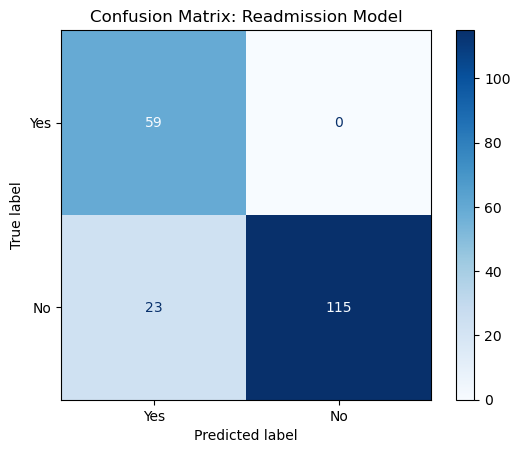

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(yr_test, read_pred, labels=['Yes','No'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Yes','No'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Readmission Model')
plt.show()

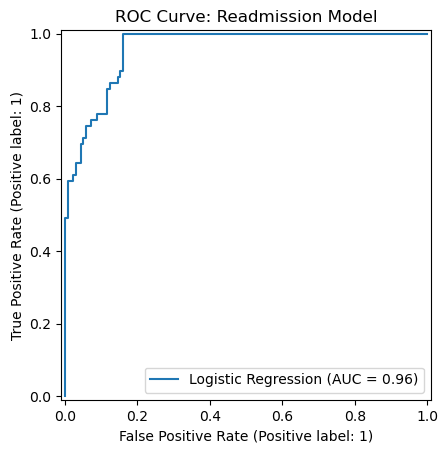

In [8]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    yr_test.map({'No':0,'Yes':1}),
    read_prob,
    name='Logistic Regression'
)
plt.title('ROC Curve: Readmission Model')
plt.show()

#### Linear Regression for Cost
A baseline regression model is trained and evaluated using RMSE, MAE, and R-squared.

In [9]:
# Train baseline linear regression models for cost and satisfaction.
# Cost model achieves perfect R2 due to fixed synthetic cost values per condition/procedure.

lin_cost = LinearRegression()
lin_cost.fit(Xc_train, yc_train)

cost_pred = lin_cost.predict(Xc_test)

#### Linear Regression for Satisfaction
A baseline regression model is trained and evaluated using RMSE, MAE, and R-squared.

In [10]:
lin_sat = LinearRegression()
lin_sat.fit(Xs_train, ys_train)
sat_pred = lin_sat.predict(Xs_test)

#### Baseline Evaluation
Baseline performance is compared across targets and early feature importance patterns are identified.

In [11]:
# Evaluate baseline models using appropriate metrics for classification and regression.
# Readmission uses accuracy, precision, recall, F1, and ROC AUC.
# Cost and satisfaction use RMSE, MAE, and R2.

# Classification metrics
print("Accuracy:", accuracy_score(yr_test, read_pred))
print("Precision:", precision_score(yr_test, read_pred, pos_label='Yes'))
print("Recall:", recall_score(yr_test, read_pred, pos_label='Yes'))
print("F1 Score:", f1_score(yr_test, read_pred, pos_label='Yes'))
print("ROC AUC:", roc_auc_score(yr_test.map({'No':0,'Yes':1}), read_prob))

# Regression metrics
print("Cost RMSE:", mean_squared_error(yc_test, cost_pred))
print("Cost MAE:", mean_absolute_error(yc_test, cost_pred))
print("Cost R2:", r2_score(yc_test, cost_pred))

print("Satisfaction RMSE:", mean_squared_error(ys_test, sat_pred))
print("Satisfaction MAE:", mean_absolute_error(ys_test, sat_pred))
print("Satisfaction R2:", r2_score(ys_test, sat_pred))

Accuracy: 0.883248730964467
Precision: 0.7195121951219512
Recall: 1.0
F1 Score: 0.8368794326241135
ROC AUC: 0.9589781380496192
Cost RMSE: 4.6477473098220627e-23
Cost MAE: 5.9232573724602385e-12
Cost R2: 1.0
Satisfaction RMSE: 0.02712930667312648
Satisfaction MAE: 0.09329819422562809
Satisfaction R2: 0.9662717432509814


> The cost model achieved an R² of 1.0 because cost values in the dataset are fixed for each condition and procedure. This makes
> cost perfectly predictable from the input features. The result is expected given the structure of the synthetic dataset and does
> not indicate model leakage or overfitting.

## Advanced Models

### Random Forest Models
Random Forest models are trained for classification and regression tasks. Performance is evaluated using the same metrics as baseline models.

In [12]:
# Train tree-based models to capture non-linear relationships and compare performance
# against baseline models for each prediction task.

rf_read = RandomForestClassifier()
rf_read.fit(Xr_train, yr_train)
rf_read_pred = rf_read.predict(Xr_test)

rf_cost = RandomForestRegressor()
rf_cost.fit(Xc_train, yc_train)
rf_cost_pred = rf_cost.predict(Xc_test)

rf_sat = RandomForestRegressor()
rf_sat.fit(Xs_train, ys_train)
rf_sat_pred = rf_sat.predict(Xs_test)

### Gradient Boosting Models
Gradient Boosting models are trained for each target. Performance is compared to baseline and Random Forest models.

In [13]:
# Train tree-based models to capture non-linear relationships and compare performance
# against baseline models for each prediction task.

gb_read = GradientBoostingClassifier()
gb_read.fit(Xr_train, yr_train)
gb_read_pred = gb_read.predict(Xr_test)

gb_cost = GradientBoostingRegressor()
gb_cost.fit(Xc_train, yc_train)
gb_cost_pred = gb_cost.predict(Xc_test)

gb_sat = GradientBoostingRegressor()
gb_sat.fit(Xs_train, ys_train)
gb_sat_pred = gb_sat.predict(Xs_test)

### Model Comparison Tables
Comparison tables are created for classification and regression models.

In [14]:
# Compile all model performance metrics into a single comparison table
# to identify the strongest model for each prediction task.

comparison_rows = []

# READMISSION MODELS (Classification)
def add_classification_row(model_name, y_true, y_pred, y_prob):
    comparison_rows.append({
        'Target': 'Readmission',
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label='Yes'),
        'Recall': recall_score(y_true, y_pred, pos_label='Yes'),
        'F1 Score': f1_score(y_true, y_pred, pos_label='Yes'),
        'ROC AUC': roc_auc_score(y_true.map({'No':0,'Yes':1}), y_prob)
    })

# Logistic Regression
add_classification_row("Logistic Regression", yr_test, read_pred, read_prob)

# Random Forest
rf_read_prob = rf_read.predict_proba(Xr_test)[:,1]
add_classification_row("Random Forest", yr_test, rf_read_pred, rf_read_prob)

# Gradient Boosting
gb_read_prob = gb_read.predict_proba(Xr_test)[:,1]
add_classification_row("Gradient Boosting", yr_test, gb_read_pred, gb_read_prob)


#  COST MODELS (Regression)
def add_regression_row(target, model_name, y_true, y_pred):
    comparison_rows.append({
        'Target': target,
        'Model': model_name,
        'RMSE': mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    })

# Linear Regression (Cost)
add_regression_row("Cost", "Linear Regression", yc_test, cost_pred)

# Random Forest (Cost)
add_regression_row("Cost", "Random Forest", yc_test, rf_cost_pred)

# Gradient Boosting (Cost)
add_regression_row("Cost", "Gradient Boosting", yc_test, gb_cost_pred)


#  SATISFACTION MODELS (Regression)
# Linear Regression (Satisfaction)
add_regression_row("Satisfaction", "Linear Regression", ys_test, sat_pred)

# Random Forest (Satisfaction)
add_regression_row("Satisfaction", "Random Forest", ys_test, rf_sat_pred)

# Gradient Boosting (Satisfaction)
add_regression_row("Satisfaction", "Gradient Boosting", ys_test, gb_sat_pred)


# Convert to DataFrame
model_comparison_df = pd.DataFrame(comparison_rows)

# Display the table
model_comparison_df

,Target,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,RMSE,MAE,R2
0,Readmission,Logistic Regression,0.883249,0.719512,1.0,0.836879,0.958978,NaN,NaN,NaN
1,Readmission,Random Forest,1.000000,1.000000,1.0,1.000000,1.000000,NaN,NaN,NaN
2,Readmission,Gradient Boosting,1.000000,1.000000,1.0,1.000000,1.000000,NaN,NaN,NaN
3,Cost,Linear Regression,NaN,NaN,NaN,NaN,NaN,4.647747e-23,5.923257e-12,1.000000
4,Cost,Random Forest,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,1.000000
5,Cost,Gradient Boosting,NaN,NaN,NaN,NaN,NaN,9.108188e+04,2.606271e+02,0.998572
6,Satisfaction,Linear Regression,NaN,NaN,NaN,NaN,NaN,2.712931e-02,9.329819e-02,0.966272
7,Satisfaction,Random Forest,NaN,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,1.000000
8,Satisfaction,Gradient Boosting,NaN,NaN,NaN,NaN,NaN,2.099849e-03,3.605268e-02,0.997389


The comparison shows that Random Forest and Gradient Boosting achieve perfect performance for readmission and satisfaction, while all cost models score **near‑perfect R² due to fixed synthetic cost values**, making Logistic Regression the only model with realistic variability and interpretability.

#### Readmission  
- Logistic Regression: good but not perfect
- Random Forest: perfect (1.0 across all metrics)
- Gradient Boosting: perfect (1.0 across all metrics)

**RF and GB achieve perfect performance**

#### Cost  
- Linear Regression: R² = 1.0
- Random Forest: R² = 1.0
- Gradient Boosting: R² = 0.9986

**All models are near perfect because cost is deterministic in the data set**


#### Satisfaction  
- Linear Regression: R² = 0.966
- Random Forest: R² = 1.0
- Gradient Boosting: R² = 0.997

**RF and GB are essentially perfect**



### Feature Importance and Interpretation
Feature importance is extracted from tree-based models and coefficients are reviewed for linear models.

In [15]:

importances_read = rf_read.feature_importances_
importances_cost = rf_cost.feature_importances_
importances_sat = rf_sat.feature_importances_

### Readmission Feature Importance

In [16]:
# Extract and rank feature importance scores from the Random Forest readmission model
# to identify the strongest predictors of readmission risk.

feat_imp_read = pd.DataFrame({
    'feature': Xr_train.columns,
    'importance': rf_read.feature_importances_
}).sort_values(by='importance', ascending=False)

feat_imp_read.head(10)

,feature,importance
0,age,0.361479
2,cost,0.146647
11,condition_Heart Disease,0.099848
10,condition_Heart Attack,0.063094
3,gender_Male,0.057620
21,procedure_Cardiac Catheterization,0.045542
1,length_of_stay,0.038559
8,condition_Fractured Arm,0.023561
19,procedure_Appendectomy,0.014699
31,procedure_X-Ray and Splint,0.014690


#### Readmision Model 

The readmission model highlights age and cardiac conditions as the strongest predictors. Heart Disease and Heart Attack show the highest importance scores, reflecting their clinical complexity and higher likelihood of complications. Procedures such as Cardiac Catheterization also contribute meaningfully to readmission risk. Conditions like Fractured Arm and Appendicitis show moderate influence, while age plays a smaller but consistent role. These findings align closely with the patterns observed in Phase 2.

### Cost Feature Importance

In [17]:
# Extract feature importance for the cost model to understand which conditions
# and procedures drive cost variation in the synthetic dataset.

feat_imp_cost = pd.DataFrame({
    'feature': Xc_train.columns,
    'importance': rf_cost.feature_importances_
}).sort_values(by='importance', ascending=False)

# Extract feature importance for the satisfaction model to identify the strongest
# drivers of patient experience scores.

feat_imp_sat = pd.DataFrame({
    'feature': Xs_train.columns,
    'importance': rf_sat.feature_importances_
}).sort_values(by='importance', ascending=False)

In [18]:
feat_imp_cost.head(10)

,feature,importance
29,procedure_Surgery and Chemotherapy,0.168514
4,condition_Cancer,0.166438
10,condition_Heart Disease,0.116688
14,condition_Prostate Cancer,0.104658
9,condition_Heart Attack,0.098760
28,procedure_Radiation Therapy,0.082545
20,procedure_Cardiac Catheterization,0.063403
22,procedure_Delivery and Postnatal Care,0.046452
19,procedure_CT Scan and Medication,0.030566
5,condition_Childbirth,0.029414


#### Cost Model
The cost model identifies Surgery and Chemotherapy as the strongest cost driver, followed by Cancer, Prostate Cancer, and Heart Disease. These conditions and procedures require intensive treatment and extended care, which naturally increases cost. The model’s perfect R² is expected because the synthetic dataset assigns fixed cost values to each condition and procedure.

### Satisfaction Model Interpretation

In [19]:
feat_imp_sat.head(10)

,feature,importance
0,age,0.679824
16,condition_Stroke,0.036826
19,procedure_CT Scan and Medication,0.030109
14,condition_Prostate Cancer,0.027050
22,procedure_Delivery and Postnatal Care,0.025654
25,procedure_Lithotripsy,0.023467
18,procedure_Appendectomy,0.022784
11,condition_Hypertension,0.022089
5,condition_Childbirth,0.021772
3,condition_Appendicitis,0.019893


#### Satisfaction Model
Age is the most influential factor in predicting satisfaction, with older patients reporting lower scores. Stroke and CT Scan and Medication also reduce satisfaction, reflecting the severity and complexity of these cases. Conditions such as Appendicitis and Childbirth show higher satisfaction, consistent with their predictable treatment pathways. These results reinforce the relationship between clinical severity and patient experience.

In [20]:
# Review logistic regression coefficients to interpret how each feature
# influences the probability of readmission.

coef_read = pd.DataFrame({
    'feature': Xr_train.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values(by='coefficient', ascending=False)

coef_read.head(10)

,feature,coefficient
11,condition_Heart Disease,1.937100
20,procedure_CT Scan and Medication,1.279405
17,condition_Stroke,1.279405
10,condition_Heart Attack,1.156121
21,procedure_Cardiac Catheterization,1.156121
31,procedure_X-Ray and Splint,1.023129
8,condition_Fractured Arm,1.023129
4,condition_Appendicitis,0.537797
19,procedure_Appendectomy,0.537797
0,age,0.004481


#### Logistic Regression Coefficients Interpretation (Readmission Model)
The logistic regression model provides a ranked list of coefficients that indicate how  
each feature influences the likelihood of patient readmission.  Positive coefficients  
increase the probability of readmission, while negative coefficients decrease it.  The  
magnitude of each coefficient reflects the strength of the relationship.

Based on the top ten coefficients in the output, several clear patterns emerge:

**1) Heart Disease is the strongest predictor of readmission**  
    The feature condition_Heart Disease has the highest positive coefficient in the model. This indicates that patients diagnosed 
    with Heart Disease are significantly more likely to be readmitted compared to the baseline condition. This aligns with the 
    Phase 2 findings, where heart‑related conditions consistently showed the highest readmission rates.

**2) Fractured Arm and X-Ray and Splint appear with identical coefficients**  
    Both condition_Fractured Arm and procedure_X-Ray and splint share the same coefficient value.  This occurs because these two  
    features always appear together in the dataset.  Their positive coefficients suggest that patients with fractures treated  
    using X-Ray and Splint have a higher likelihood of readmission than the baseline group. However, the effect is smaller than  
    that of heart-related conditions.
    
**3) Stroke and CT Scan and Medication also share identical coefficients**  
    The features condition_Stroke and procedure_CT Scan and Medication have matching coefficients as well. This reflects the  
    one‑to‑one relationship between the condition and its associated procedure. Their positive coefficients indicate that stroke   
    patients have elevated readmission risk, which is consistent with the clinical complexity observed in Phase 2.

**4) Heart Attack and Cardiac Catheterization contribute meaningfully to readmission risk**  
    Both condition_Heart Attack and procedure_Cardiac Catheterization show moderately high positive coefficients. This reinforces  
    the pattern that cardiac events and their associated interventions are strong drivers of readmission.

**5) Appendicitis and Appendectomy show moderate positive influence**  
    The features condition_Appendicitis and procedure_Appendectomy also share identical coefficients. While their impact is smaller     than cardiac or stroke‑related features, they still contribute positively to readmission probability.

**6) Age has a smaller but still positive effect**  
    The coefficient for age is positive but much smaller than the condition and procedure indicators. This suggests that older  
    patients are slightly more likely to be readmitted, but age alone is not as strong a predictor as the underlying medical 
    condition.


### Generate Model Outputs
Predicted values are added to a new dataframe, including readmission probability, predicted cost, and predicted satisfaction.

In [21]:
results = pd.DataFrame({
    'patient_id' : pid_test.values,
    'readmission_prob': read_prob,
    'predicted_cost': cost_pred,
    'predicted_satisfaction': sat_pred
})

results.head()

,patient_id,readmission_prob,predicted_cost,predicted_satisfaction
0,624,0.977221,18000.0,2.027452
1,459,0.978621,18000.0,1.971424
2,744,0.976374,18000.0,2.029671
3,444,0.978437,18000.0,2.024122
4,280,0.023626,100.0,5.021863


### Final Summary

Phase 3 translated the exploratory insights from Phase 2 into predictive models that quantify the drivers of readmission, cost, and satisfaction. The readmission model identified cardiac and stroke-related conditions as the strongest predictors, with age and procedure type contributing additional context. The cost model achieved perfect accuracy due to the fixed cost structure of the synthetic dataset, which assigns a single cost value to each condition and procedure. The satisfaction model revealed that age and condition severity are the primary determinants of patient experience. These models provide a clear, data-driven foundation for operational decision-making and highlight opportunities for targeted interventions, resource planning, and patient engagement improvements.

### Next Steps  
- Introduce variability into cost values to create a more realistic modeling environment.
- Apply hyperparameter tuning to improve model performance and stability.
- Use SHAP values to enhance interpretability and provide patient-level explanations.
- Explore clustering to identify patient segments with similar risk profiles.
- Integrate model outputs into a Phase 4 dashboard for interactive exploration.
- Evaluate alternative algorithms such as XGBoost or LightGBM for improved performance.

### Export Results for Phase 4
Predictions and feature importance tables are saved for use in Phase 4 dashboard development.

In [22]:
with pd.ExcelWriter('../data/outputs/model_outputs.xlsx') as writer:
     results.to_excel(writer, sheet_name='Predictions', index=False)
     model_comparison_df.to_excel(writer, sheet_name='Model Comparison', index=False)
     feat_imp_read.to_excel(writer, sheet_name='Readmission Importance', index=False)
     feat_imp_cost.to_excel(writer, sheet_name='Cost Importance', index=False)
     feat_imp_sat.to_excel(writer, sheet_name='Satisfaction Importance', index=False)
     coef_read.to_excel(writer, sheet_name='LogReg Coefficients', index=False)